# Matplotlib: A Complete Guide

Matplotlib is the foundational plotting library in Python. It is designed
around a simple philosophy: you should be able to create a basic plot with
just a few commands. This module covers everything from that first plot
through to intermediate customisation, practical tips, and a full API
reference drawn from the official Matplotlib handouts and cheatsheets.

**Module overview**

1. **The Four-Step Workflow** - initialise, prepare, render, observe
2. **Choosing a Chart Type** - the full gallery of plot kinds
3. **Tweaking Appearance** - colours, line styles, linewidth, markers
4. **Organising Plots** - multiple series and subplots
5. **Labelling** - titles, axis labels, and the figure supertitle
6. **Saving Figures** - bitmap and vector formats
7. **Anatomy of a Figure** - the hierarchy of Matplotlib elements
8. **Figure, Axes and Spines** - grid specs and spine control
9. **Ticks and Labels** - locators, formatters, and rotation
10. **Lines, Markers and Scales** - format strings and log scales
11. **Text and Ornaments** - fill, text, and LaTeX annotations
12. **Legends** - placement, anchoring, and layout
13. **Annotations** - arrows and callouts
14. **Colours** - named colours, Hex codes, and the default cycle
15. **Size and DPI** - controlling figure dimensions
16. **Tips and Tricks** - transparency, rasterization, typography, hatching
17. **Cheatsheet Reference** - advanced plots, tick API, event handling,
    animation, styles, and quick how-tos

## Part 1 - Getting Started (Beginner)

Source: *Matplotlib for Beginners* handout (Matplotlib 3.10.8)

## The Four-Step Workflow

Every Matplotlib figure follows the same four steps: initialise the
libraries, prepare the data, render the figure, then observe the result.

### Step 1 - Initialise

In [432]:
import numpy as np
import matplotlib.pyplot as plt

### Step 2 - Prepare

`np.linspace` generates evenly spaced values over a specified interval.
Here we create 1000 points from 0 to 10π, giving a smooth sine wave.

In [433]:
X = np.linspace(0, 10*np.pi, 1000)
Y = np.sin(X)

### Step 3 - Render

`plt.subplots()` returns a `Figure` and an `Axes` object. The `Axes` is where
all the plotting happens. Calling `plt.show()` displays the figure; in Jupyter
with the inline backend the figure renders automatically, but `plt.show()` is
still good practice for scripts.

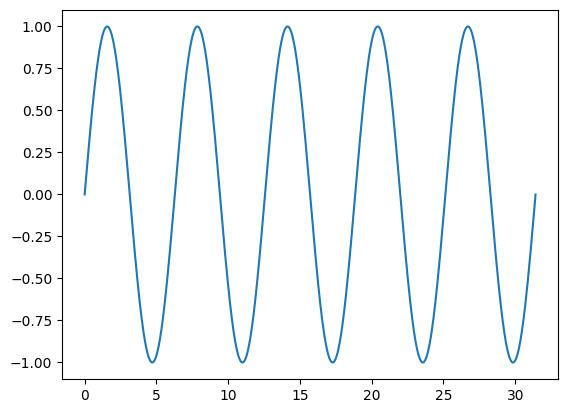

In [434]:
fig, ax = plt.subplots()
ax.plot(X, Y)
plt.show()

## Choosing a Chart Type

Matplotlib offers many plot types. Each one is a method on the `Axes` object.
The examples below show the data shapes each type expects.

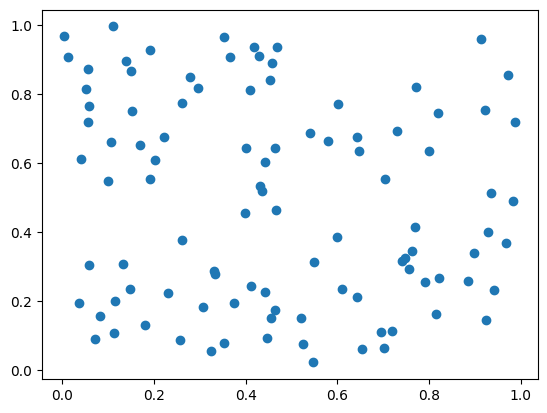

In [435]:
# Scatter plot - two arrays of equal length for X and Y positions
X = np.random.uniform(0, 1, 100)
Y = np.random.uniform(0, 1, 100)

fig, ax = plt.subplots()
ax.scatter(X, Y)
plt.show()

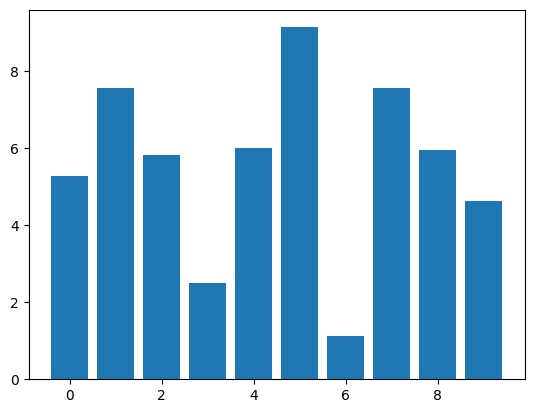

In [436]:
# Bar chart - integer positions on X, heights on Y
X = np.arange(10)
Y = np.random.uniform(1, 10, 10)

fig, ax = plt.subplots()
ax.bar(X, Y)
plt.show()

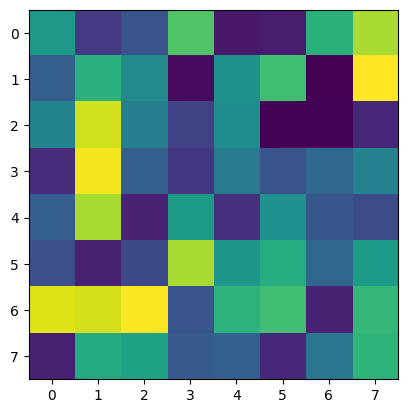

In [437]:
# Image / heatmap - a 2D array rendered as a colour grid
Z = np.random.uniform(0, 1, (8, 8))

fig, ax = plt.subplots()
ax.imshow(Z)
plt.show()

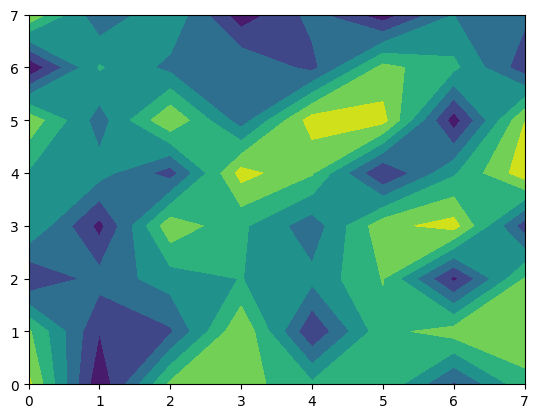

In [438]:
# Filled contour plot - another 2D array, now shown as filled contour regions
Z = np.random.uniform(0, 1, (8, 8))

fig, ax = plt.subplots()
ax.contourf(Z)
plt.show()

In [439]:
help(ax.pie)

Help on method pie in module matplotlib.axes._axes:

pie(x, *, explode=None, labels=None, colors=None, autopct=None, pctdistance=0.6, shadow=False, labeldistance=1.1, startangle=0, radius=1, counterclock=True, wedgeprops=None, textprops=None, center=(0, 0), frame=False, rotatelabels=False, normalize=True, hatch=None, data=None) method of matplotlib.axes._axes.Axes instance
    Plot a pie chart.

    Make a pie chart of array *x*.  The fractional area of each wedge is
    given by ``x/sum(x)``.

    The wedges are plotted counterclockwise, by default starting from the
    x-axis.

    Parameters
    ----------
    x : 1D array-like
        The wedge sizes.

    explode : array-like, default: None
        If not *None*, is a ``len(x)`` array which specifies the fraction
        of the radius with which to offset each wedge.

    labels : list, default: None
        A sequence of strings providing the labels for each wedge

    colors : :mpltype:`color` or list of :mpltype:`color`, defaul

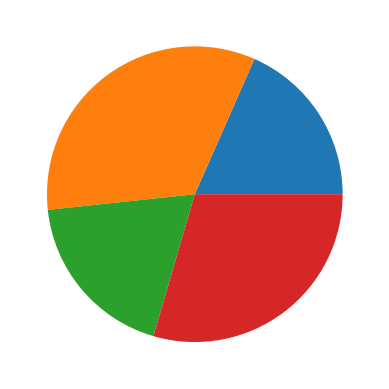

In [440]:
Z = np.random.uniform(0, 1, 4)

fig, ax = plt.subplots()
ax.pie(Z)
plt.show()

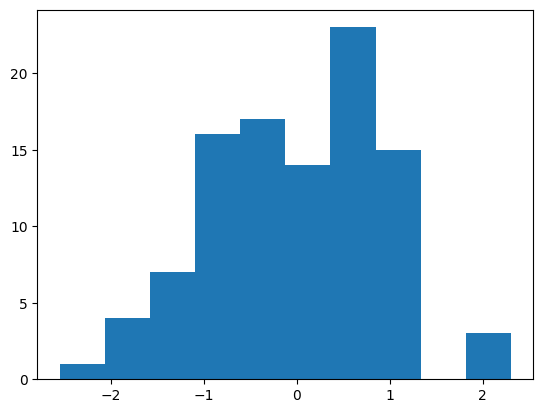

In [441]:
# Histogram - a 1D array of raw values; Matplotlib bins them automatically
Z = np.random.normal(0, 1, 100)

fig, ax = plt.subplots()
ax.hist(Z)
plt.show()

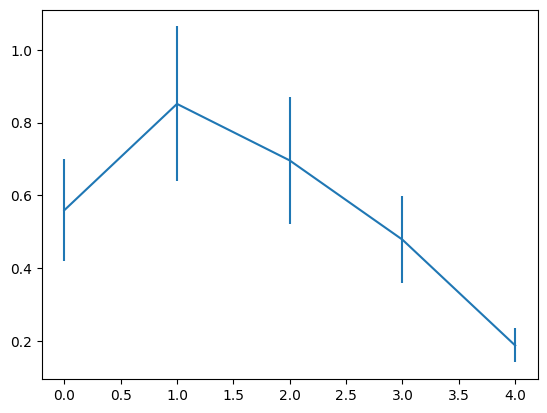

In [442]:
# Error bar plot - X positions, Y values, and error sizes
X = np.arange(5)
Y = np.random.uniform(0, 1, 5)

fig, ax = plt.subplots()
ax.errorbar(X, Y, Y/4)
plt.show()

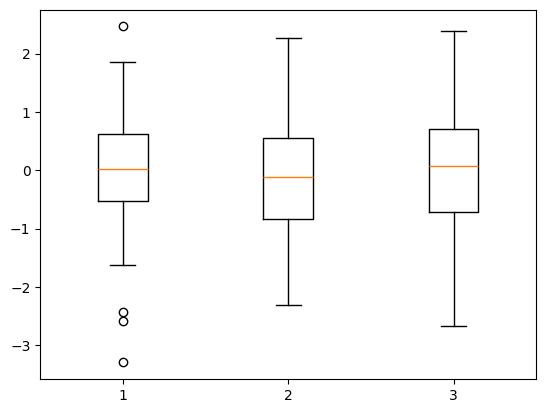

In [443]:
# Box plot - a 2D array; each column becomes one box
Z = np.random.normal(0, 1, (100, 3))

fig, ax = plt.subplots()
ax.boxplot(Z)
plt.show()

## Tweaking Appearance

Most visual properties are keyword arguments on the plot call. The four most
common ones are colour, line style, linewidth, and marker.

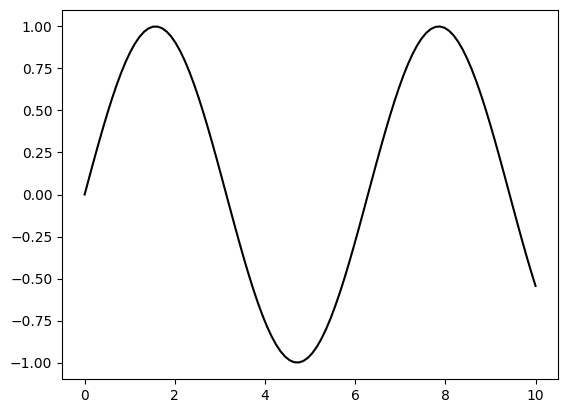

In [444]:
X = np.linspace(0, 10, 100)
Y = np.sin(X)

# colour - accepts colour names, Hex codes, or short single-letter codes
fig, ax = plt.subplots()
ax.plot(X, Y, color="black")
plt.show()

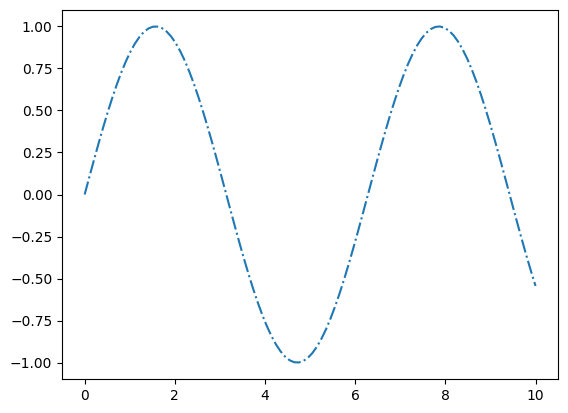

In [445]:
# linestyle - controls the dash pattern of the line
fig, ax = plt.subplots()
ax.plot(X, Y, linestyle="-.")
plt.show()

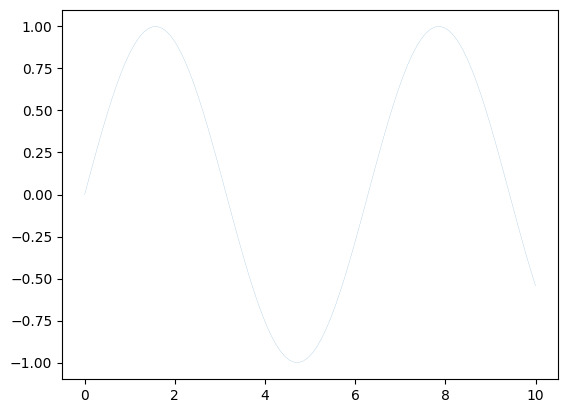

In [446]:
# linewidth - controls line thickness in points
fig, ax = plt.subplots()
ax.plot(X, Y, linewidth=0.1)
plt.show()

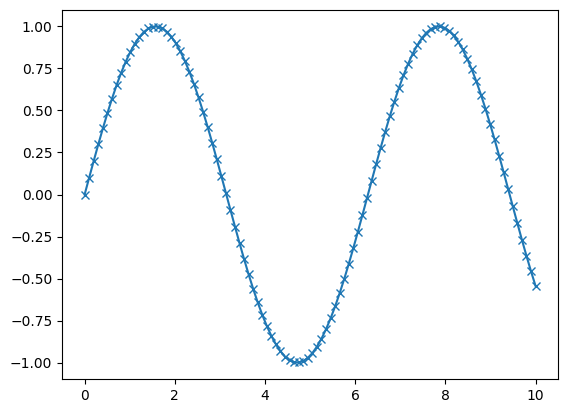

In [447]:
# marker - places a symbol at each data point
fig, ax = plt.subplots()
ax.plot(X, Y, marker="x")
plt.show()

## Organising Multiple Series and Subplots

Multiple series can be drawn on the same `Axes`, or split into separate
subplots. `plt.subplots(rows, cols)` creates a grid of `Axes` objects.

In [448]:
num1 = 5
num2 = 7

num1, num2 = 5, 7

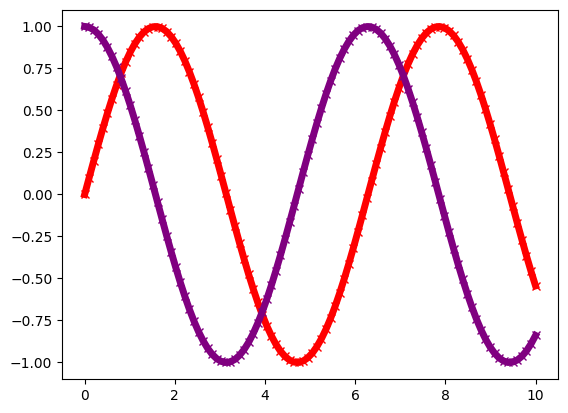

In [449]:
X = np.linspace(0, 10, 100)
Y1, Y2 = np.sin(X), np.cos(X)

# Both series on the same axes - pass them as alternating X, Y pairs
fig, ax = plt.subplots()
ax.plot(X, Y1, linewidth=5, marker='x', color="red")
ax.plot(X, Y2, linewidth=5, marker='x', color="purple")
plt.show()

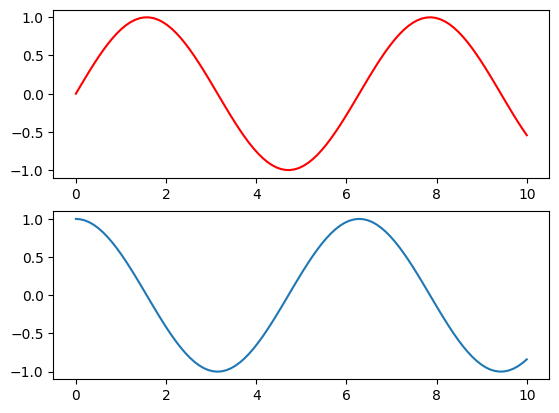

In [450]:
# Two rows, one column - stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(X, Y1, color="red")
ax2.plot(X, Y2, color="C0")
plt.show()

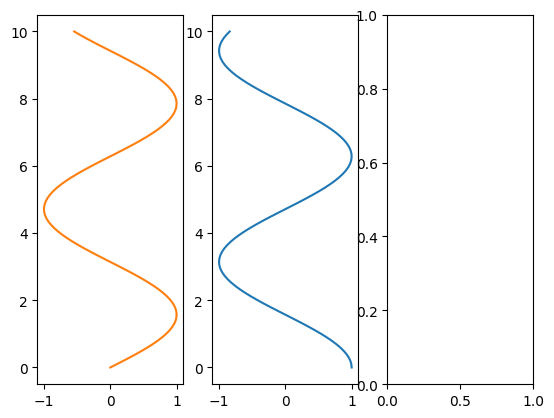

In [451]:
# One row, two columns - side by side
# Note: plotting Y against X here swaps the axes (horizontal sine/cosine)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
ax1.plot(Y1, X, color="C1")
ax2.plot(Y2, X, color="C0")
# ax3.plot(Y2, X, color="C0")
plt.show()

## Labelling

Every chart shared with an audience needs a title and labelled axes.
`ax.set_title()` labels the individual subplot; `fig.suptitle()` labels the
entire figure when there are multiple subplots.

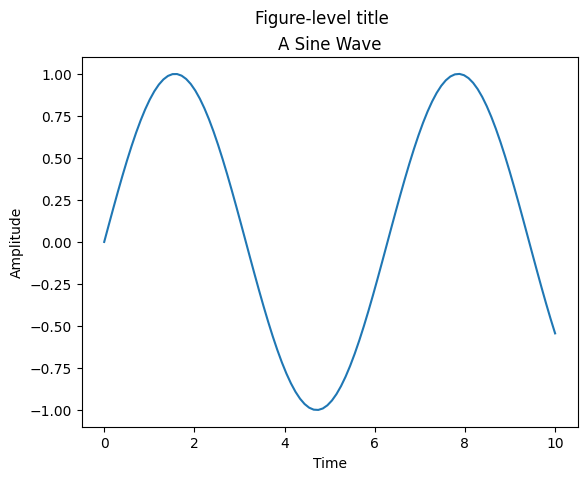

In [452]:
X = np.linspace(0, 10, 100)
Y = np.sin(X)

fig, ax = plt.subplots()
ax.plot(X, Y)
fig.suptitle("Figure-level title")
ax.set_title("A Sine Wave")
ax.set_xlabel("Time")
ax.set_ylabel("Amplitude")
plt.show()

## Saving Figures

`fig.savefig()` writes the figure to disk. The format is inferred from the
file extension. Use `dpi=` to control resolution for bitmap formats.
PDF and SVG are vector formats and scale without quality loss.

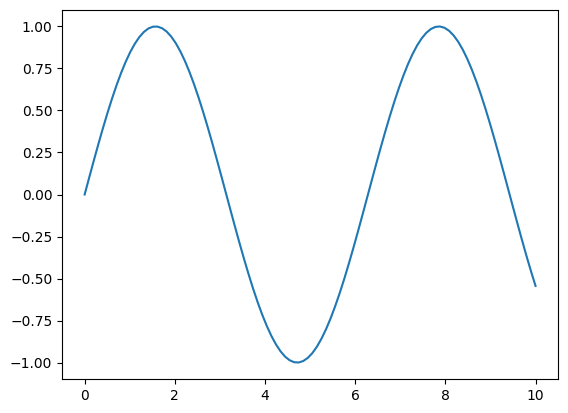

In [453]:
fig, ax = plt.subplots()
ax.plot(np.linspace(0, 10, 100), np.sin(np.linspace(0, 10, 100)))

# Bitmap format - 300 DPI is standard for print quality
fig.savefig("my-first-figure.png", dpi=300)

# Vector format - resolution-independent, ideal for reports and slides
fig.savefig("my-first-figure.pdf")

## Part 2 - Intermediate

Source: *Matplotlib for Intermediate Users* handout (Matplotlib 3.10.8)

A Matplotlib figure is a hierarchy of nested objects. Understanding that
hierarchy is what makes it possible to modify any element of a chart:

- **Figure** - the outermost container; holds all other elements
- **Axes** - the plot area including ticks, labels, and data (not axis lines)
- **Spines** - the four border lines around an Axes
- **Axis** - the X or Y axis object that manages ticks and limits
- **Artist** - everything drawn on a figure (lines, text, patches) is an
  Artist

## Figure, Axes and Spines

### Accessing individual subplots

When `plt.subplots()` returns more than one Axes, they come back as a 2D
NumPy array indexed by `[row, col]`.

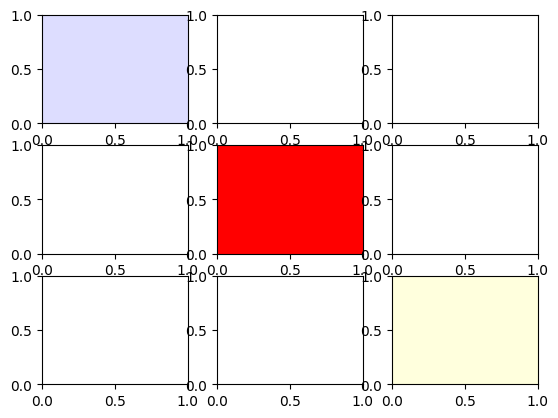

In [454]:
fig, axs = plt.subplots(3, 3)
axs[0, 0].set_facecolor("#ddddff")   # top-left cell - light blue
axs[1, 1].set_facecolor("#ff0000")
axs[2, 2].set_facecolor("#ffffdd")   # bottom-right cell - light yellow
plt.show()

### GridSpec for irregular layouts

`add_gridspec` followed by `add_subplot` lets one subplot span multiple rows
or columns using slice notation.

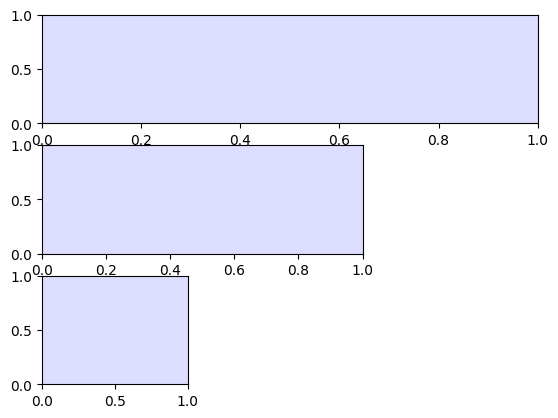

In [455]:
fig = plt.figure()
gs = fig.add_gridspec(3, 3)
ax = fig.add_subplot(gs[0, :])        # first row, all three columns
ax.set_facecolor("#ddddff")
ax2 = fig.add_subplot(gs[1, :2])        # second row, first two columns
ax2.set_facecolor("#ddddff")
ax3 = fig.add_subplot(gs[2, :1])        # second row, first two columns
ax3.set_facecolor("#ddddff")
plt.show()

### Hiding spines

Removing the top and right spines gives a cleaner look for many chart types.

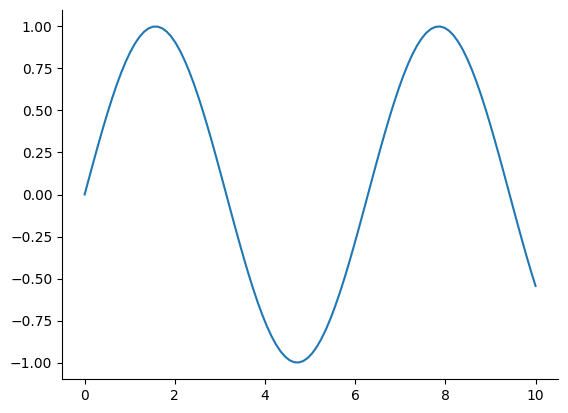

In [456]:
fig, ax = plt.subplots()
ax.plot(np.linspace(0, 10, 100), np.sin(np.linspace(0, 10, 100)))
ax.spines["top"].set_color("None")
ax.spines["right"].set_color("None")
plt.show()

## Ticks and Labels

Matplotlib separates tick *location* from tick *formatting*. A `Locator`
decides where ticks are placed; a `Formatter` decides how they are displayed.

Note: the handout abbreviates the import as `from mpl.ticker import ...`.
The correct import path is `from matplotlib.ticker import ...`.

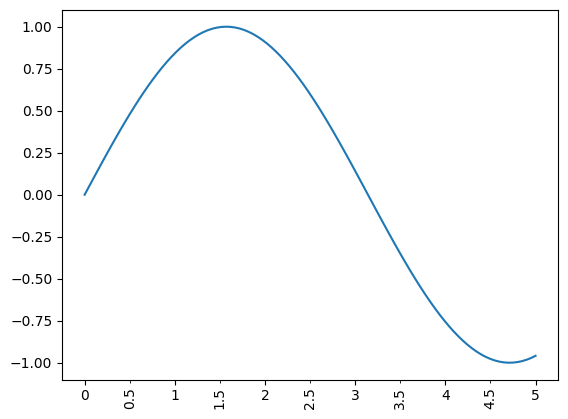

In [457]:
from matplotlib.ticker import MultipleLocator as ML
from matplotlib.ticker import ScalarFormatter as SF

fig, ax = plt.subplots()
ax.plot(np.linspace(0, 5, 100), np.sin(np.linspace(0, 5, 100)))

# Place minor ticks every 0.2 units and display them as scalar numbers
ax.xaxis.set_minor_locator(ML(0.5))
ax.xaxis.set_minor_formatter(SF())

# Rotate minor tick labels to prevent overlap
ax.tick_params(axis="x", which="minor", rotation=90)
plt.show()

## Lines and Markers

Matplotlib's format string shorthand packs colour, marker, and line style
into a single string argument. `"C1o:"` means: colour C1 (orange), circle
markers, dotted line. `markevery=50` draws a marker only every 50 points to
avoid clutter; `mec="1.0"` sets the marker edge colour to white.

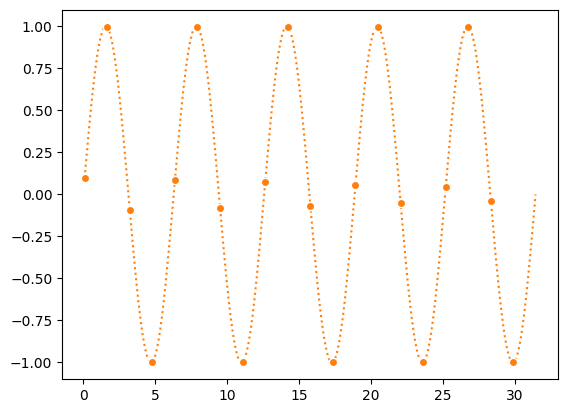

In [458]:
X = np.linspace(0.1, 10*np.pi, 1000)
Y = np.sin(X)

fig, ax = plt.subplots()
ax.plot(X, Y, "C1o:", markevery=50, mec="1.0")
plt.show()

## Scales and Projections

`ax.set_xscale("log")` switches the X-axis to a logarithmic scale. This is
useful when data spans several orders of magnitude.

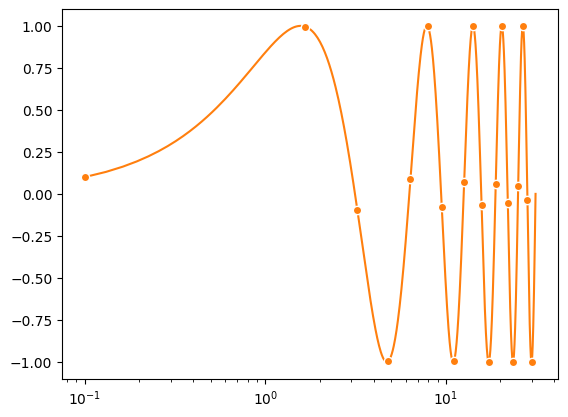

In [459]:
fig, ax = plt.subplots()
ax.set_xscale("log")
ax.plot(X, Y, "C1o-", markevery=50, mec="1.0")
plt.show()

## Text and Ornaments

`ax.fill_betweenx(y, x1, x2)` shades a region between two X values across a
given Y range. `ax.text()` places arbitrary text at data coordinates.
The `r"..."` prefix and `$...$` delimiters enable LaTeX-style maths
rendering.

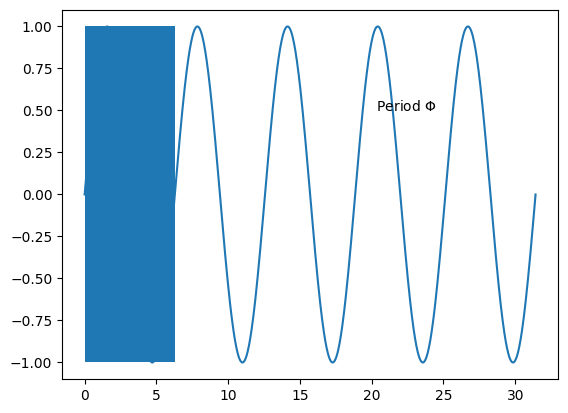

In [460]:
X = np.linspace(0, 10*np.pi, 1000)
Y = np.sin(X)

fig, ax = plt.subplots()
ax.plot(X, Y)

# Shade one full period (0 to 2π) across the full Y range of the sine wave
ax.fill_betweenx([-1, 1], [0], [2*np.pi])

# Place a label inside the shaded region
ax.text(20, 0.5, r" Period $\Phi$")
plt.show()

## Legends

Assign a `label=` string to each plotted series and call `ax.legend()` to
display them. `bbox_to_anchor` places the legend at exact figure coordinates;
`ncol` arranges entries into columns; `mode="expand"` stretches the legend to
the full width of its bounding box.

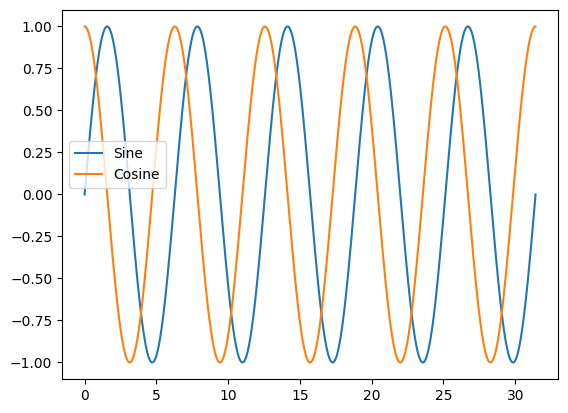

In [461]:
X = np.linspace(0, 10*np.pi, 1000)

fig, ax = plt.subplots()
ax.plot(X, np.sin(X), "C0", label="Sine")
ax.plot(X, np.cos(X), "C1", label="Cosine")
ax.legend(
    bbox_to_anchor=(0,0.5,1,.1),
    ncol=1,
    loc="lower left",
)
plt.show()

## Annotations

`ax.annotate()` draws a text label connected to a data point by an arrow.
`xy` is the point being annotated; `xytext` is where the label sits.
`arrowprops` controls the arrow style and colour.

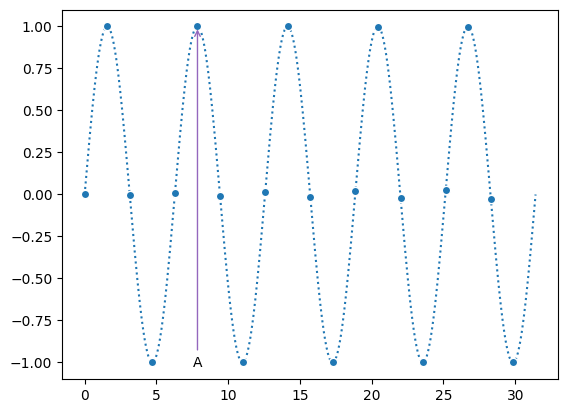

In [462]:
X = np.linspace(0, 10*np.pi, 1000)
Y = np.sin(X)

fig, ax = plt.subplots()
ax.plot(X, Y, "C0o:", markevery=50, mec="1.0")
ax.annotate(
    "A",
    (X[250], Y[250]),
    (X[250], -1),
    ha="center",
    va="center",
    arrowprops={"arrowstyle": "->", "color": "C4"},
)
plt.show()

## Colours

Matplotlib provides several ways to specify colour:

- `"C0"` through `"C9"` - the current colour cycle (blue, orange, green ...)
- Single-letter shortcuts: `"b"` blue, `"g"` green, `"r"` red, `"k"` black
- Named colours: `"black"`, `"firebrick"`, `"steelblue"`, etc.
- Hex codes: `"#FF0000"` or `"#FF000088"` (with alpha)
- RGB/RGBA tuples: `(1, 0, 0)` or `(1, 0, 0, 0.5)`
- Greyscale strings: `"0.0"` (black) through `"1.0"` (white)

The full named colour list is available in the Matplotlib documentation.

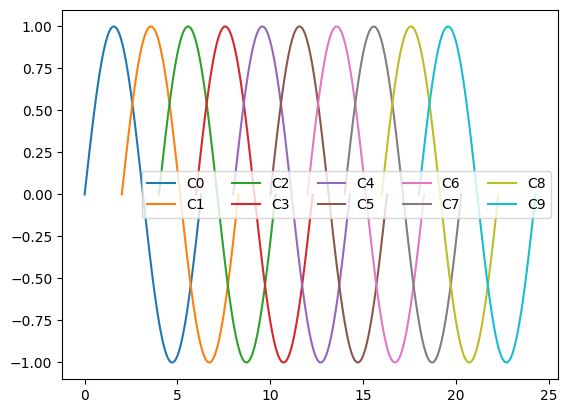

In [463]:
X = np.linspace(0, 2*np.pi, 100)

fig, ax = plt.subplots()
for i in range(10):
    ax.plot(X + i * 2, np.sin(X), color=f"C{i}", label=f"C{i}")
ax.legend(ncol=5)
plt.show()

## Size and DPI

`figsize=(width, height)` sets the figure size in inches. `dpi` sets the
resolution (dots per inch) for the screen preview. For the saved file, pass
`dpi=` to `savefig()` separately - a high-quality export from a small screen
preview is common practice.

Example: a square figure for a two-column A4 paper with 2 cm margins and a
1 cm column separator has a width of (21 - 2×2 - 1) / 2 = 8 cm. One inch is
2.54 cm, so the figure should be 3.15 × 3.15 inches.

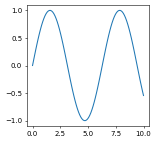

In [464]:
fig = plt.figure(figsize=(3.15, 3.15), dpi=50)
ax = fig.add_subplot()
ax.plot(np.linspace(0, 10, 100), np.sin(np.linspace(0, 10, 100)))
plt.savefig("figure.pdf", dpi=600)
plt.show()

## Part 3 - Tips and Tricks

Source: *Matplotlib Tips & Tricks* handout (Matplotlib 3.10.8)

## Transparency

Setting `alpha` below 1.0 makes markers semi-transparent. Layering multiple
scatter calls with different alpha values creates a density effect: opaque
outlines first, then a filled layer at low alpha to show where points cluster.

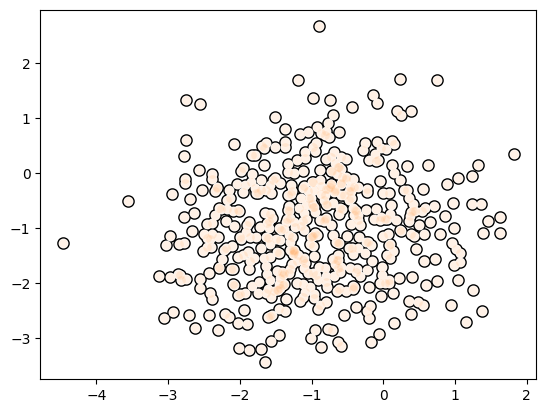

In [465]:
X = np.random.normal(-1, 1, 500)
Y = np.random.normal(-1, 1, 500)

fig, ax = plt.subplots()
ax.scatter(X, Y, 50, "0.0", lw=2)          # dark outline ring (optional)
ax.scatter(X, Y, 50, "1.0", lw=0)          # white fill to separate layers (optional)
ax.scatter(X, Y, 40, "C1", lw=0, alpha=0.1)  # coloured fill at low opacity
plt.show()

## Rasterization

When a figure contains tens of thousands of graphical elements (a large
scatter, for example), saving it as a pure vector PDF produces a huge file
that renders slowly. Setting `rasterized=True` on those elements converts
just them to a bitmap at the given DPI, while keeping text and other
elements in vector format.

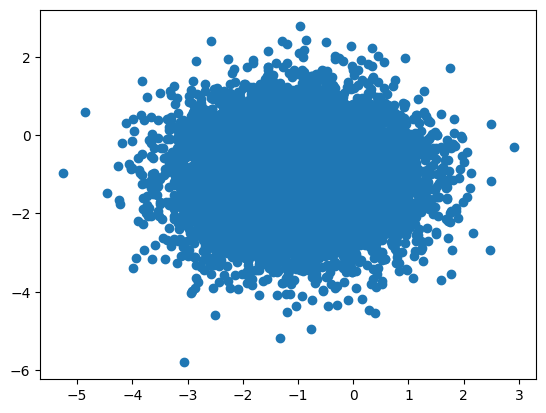

In [466]:
X = np.random.normal(-1, 1, 10_000)
Y = np.random.normal(-1, 1, 10_000)

fig, ax = plt.subplots()
ax.scatter(X, Y, rasterized=True)
fig.savefig("rasterized-figure.pdf", dpi=600)
plt.show()

## Offline Rendering

The Agg backend can render a figure directly into a NumPy array without
displaying a window. This is useful for generating images in scripts or
server-side applications.

Note: the handout shows `FigureCanvas(Figure()))` with an extra bracket - the
correct call is `FigureCanvas(Figure())`. `Figure` must also be imported from
`matplotlib.figure`.

In [467]:
from matplotlib.backends.backend_agg import FigureCanvas
from matplotlib.figure import Figure

canvas = FigureCanvas(Figure())
canvas.figure.add_subplot().plot(
    np.linspace(0, 10, 100),
    np.sin(np.linspace(0, 10, 100)),
)
canvas.draw()
Z = np.array(canvas.renderer.buffer_rgba())
print("Rendered array shape:", Z.shape)   # (height, width, 4) - RGBA channels

Rendered array shape: (480, 640, 4)


## Range of Continuous Colours

Colormaps can be sampled at specific positions (0.0 to 1.0) to extract a
list of colours. This is useful for giving grouped bars or lines a coherent
tonal progression.

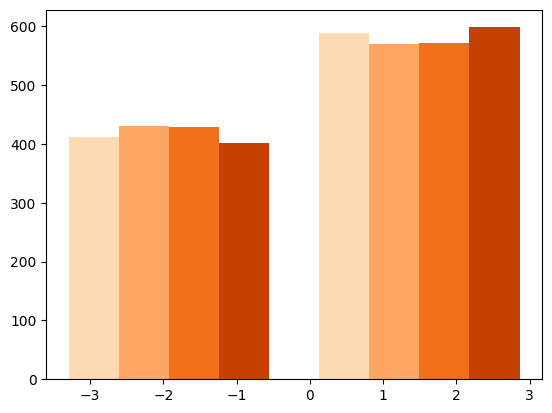

In [468]:
X = np.random.randn(1000, 4)

cmap = plt.get_cmap("Oranges")
colors = cmap([0.2, 0.4, 0.6, 0.8])    # four shades from light to dark orange

fig, ax = plt.subplots()
ax.hist(X, 2, histtype="bar", color=colors)
plt.show()

## Text Outline

A thin white stroke behind dark text makes it readable against busy
backgrounds without needing a white box. `patheffects` achieves this by
stacking a `Stroke` effect underneath the normal render.

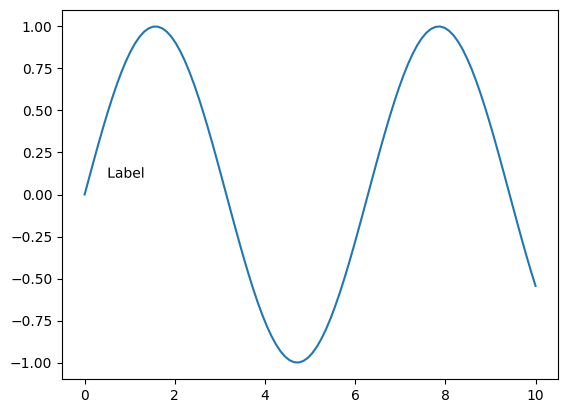

In [469]:
import matplotlib.patheffects as fx

fig, ax = plt.subplots()
ax.plot(np.linspace(0, 10, 100), np.sin(np.linspace(0, 10, 100)))

text = ax.text(0.5, 0.1, "Label")
text.set_path_effects([
    fx.Stroke(linewidth=3, foreground="1.0"),   # white halo
    fx.Normal(),                                 # normal text on top
])
plt.show()

## Multiline Plot

To draw many disconnected vertical segments efficiently, build a single flat
array with `None` as a separator between segments and call `plot` once.
`None` values create a break in the line without starting a new `plot` call.

Note: the handout uses bare `sin`; use `np.sin` when NumPy is the only
import.

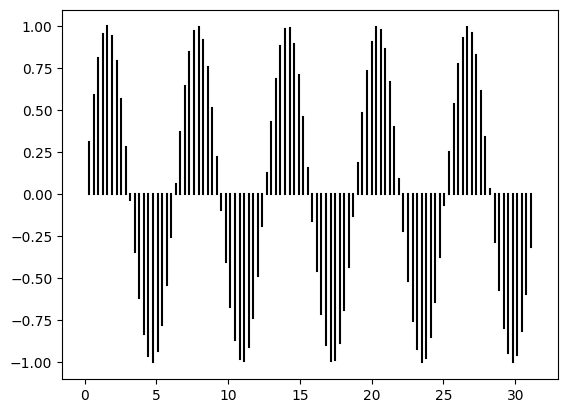

In [470]:
X, Y = [], []
for x in np.linspace(0, 10*np.pi, 100):
    X.extend([x, x, None])
    Y.extend([0, np.sin(x), None])

fig, ax = plt.subplots()
ax.plot(X, Y, "black")
plt.show()

## Dotted Lines

A custom `linestyle` tuple `(offset, (on_length, off_length))` combined with
`dash_capstyle="round"` produces clean rounded dots instead of dashes.
Increasing the off_length spaces the dots further apart.

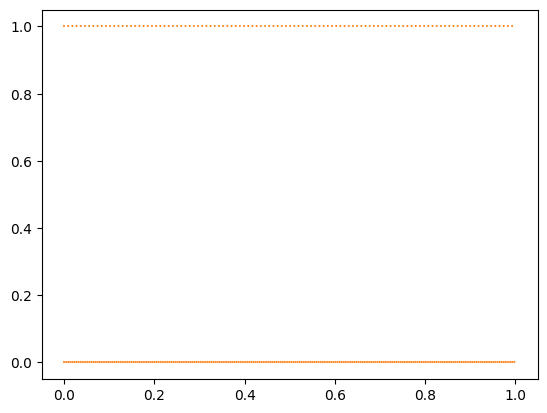

In [471]:
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 0], "C1",
        linestyle=(0, (0.01, 1)), dash_capstyle="round")
ax.plot([0, 1], [1, 1], "C1",
        linestyle=(0, (0.01, 2)), dash_capstyle="round")
plt.show()

## Combining Axes

Two Axes can be overlaid on the same figure area using `fig.add_axes` with
different `projection` and `label` arguments. This allows, for instance, a
Cartesian and a polar plot to share the same space.

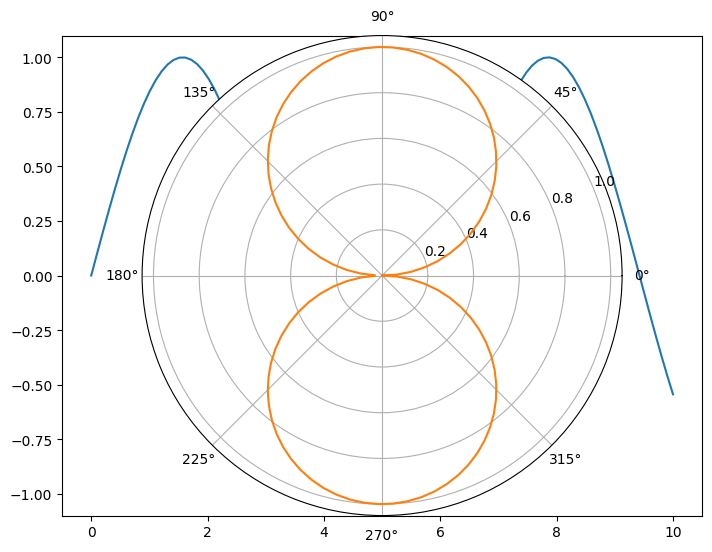

In [472]:
fig = plt.figure()
ax1 = fig.add_axes([0, 0, 1, 1], label="cartesian")
ax2 = fig.add_axes([0, 0, 1, 1], label="polar", projection="polar")

ax1.plot(np.linspace(0, 10, 100), np.sin(np.linspace(0, 10, 100)), "C0")
ax2.plot(np.linspace(0, 2*np.pi, 100), np.abs(np.sin(np.linspace(0, 2*np.pi, 100))), "C1")
plt.show()

## Colourbar Adjustment

`fraction` and `pad` control the width and spacing of a colourbar relative
to the Axes. `cb.set_ticks([])` removes the tick marks entirely, leaving
just the colour gradient.

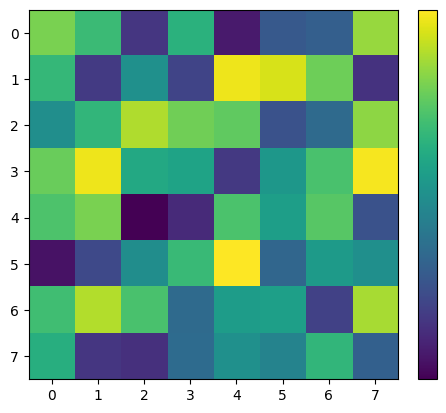

In [473]:
Z = np.random.uniform(0, 1, (8, 8))

fig, ax = plt.subplots()
im = ax.imshow(Z)
cb = plt.colorbar(im, fraction=0.046, pad=0.04)
cb.set_ticks([])
plt.show()

## Typography on Tick Labels

A condensed font on tick labels saves horizontal space on dense axes. Loop
through the tick label objects and call `set_fontname()` on each one.

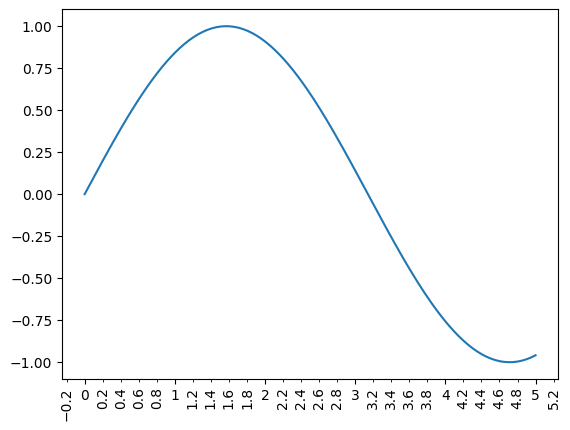

In [474]:
fig, ax = plt.subplots()
ax.plot(np.linspace(0, 5, 200), np.sin(np.linspace(0, 5, 200)))
ax.xaxis.set_minor_locator(ML(0.2))
ax.xaxis.set_minor_formatter(SF())
ax.tick_params(axis="x", which="minor", rotation=90)

for tick in ax.get_xticklabels(which="both"):
    tick.set_fontname("times new roman")   # substitute any installed condensed font
plt.show()

## Getting Rid of Margins

`fig.tight_layout()` recalculates spacing to remove excess white space around
subplots. Call it after all plotting is complete, just before saving or
showing.

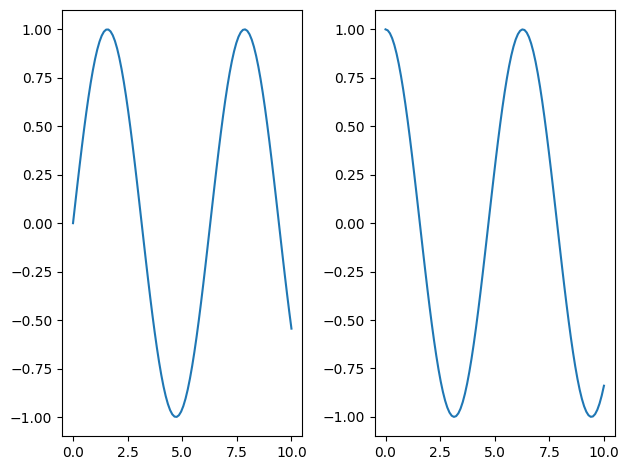

In [475]:
fig, (ax1, ax2) = plt.subplots(1, 2)
X = np.linspace(0, 10, 100)
ax1.plot(X, np.sin(X))
ax2.plot(X, np.cos(X))
fig.tight_layout()
plt.show()

## Hatching

Thick hatch patterns applied to bars create a visually distinct fill that
works well in greyscale printing. Set `rcParams` to control hatch colour and
linewidth globally before drawing.

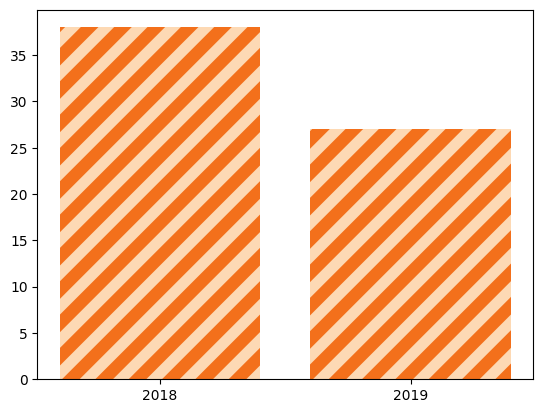

In [476]:
X = np.arange(2)
Y = np.array([38, 27])

cmap = plt.get_cmap("Oranges")
plt.rcParams["hatch.color"] = cmap(0.2)
plt.rcParams["hatch.linewidth"] = 8

fig, ax = plt.subplots()
ax.bar(X, Y, color=cmap(0.6), hatch="/")
ax.set_xticks(X)
ax.set_xticklabels(["2018", "2019"])
plt.show()

## Part 4 - Cheatsheet Reference

Source: *Matplotlib Cheatsheets* (Matplotlib 3.10.8)

This section documents the full plotting API, covering basic and advanced
chart types, scales, projections, tick control, legends, animation, styles,
and practical how-tos from the official cheatsheets.

## Quick Start API

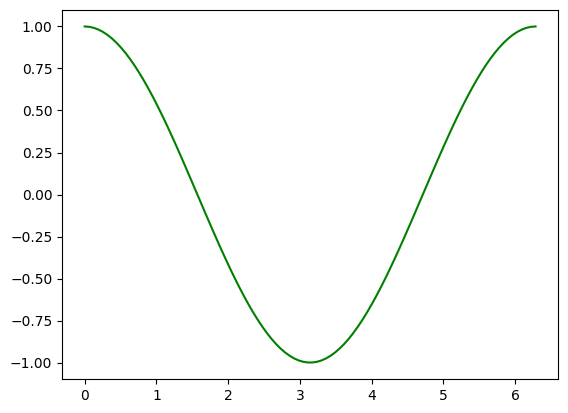

In [477]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

X = np.linspace(0, 2*np.pi, 100)
Y = np.cos(X)

fig, ax = plt.subplots()
ax.plot(X, Y, color='green')
fig.savefig("figure.pdf")
plt.show()

## Basic Plots API

All basic plot types share a common call convention: the data arrays come
first, followed by keyword arguments for visual properties.

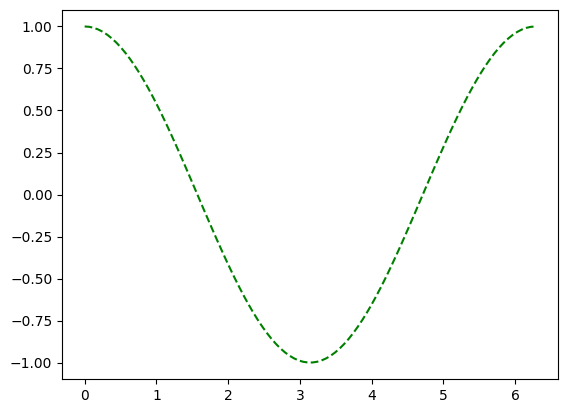

In [478]:
X = np.linspace(0, 2*np.pi, 100)
Y = np.cos(X)

# plot - line chart; fmt shorthand combines colour, marker, linestyle
fig, ax = plt.subplots()
ax.plot(X, Y, "g--")       # green dashed line
plt.show()

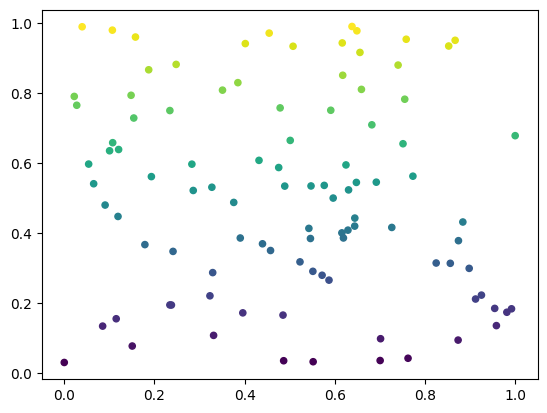

In [479]:
# scatter - raw point cloud; s= sizes, c= colours (per-point)
X = np.random.uniform(0, 1, 100)
Y = np.random.uniform(0, 1, 100)

fig, ax = plt.subplots()
ax.scatter(X, Y, s=20, c=Y, cmap="viridis")
plt.show()

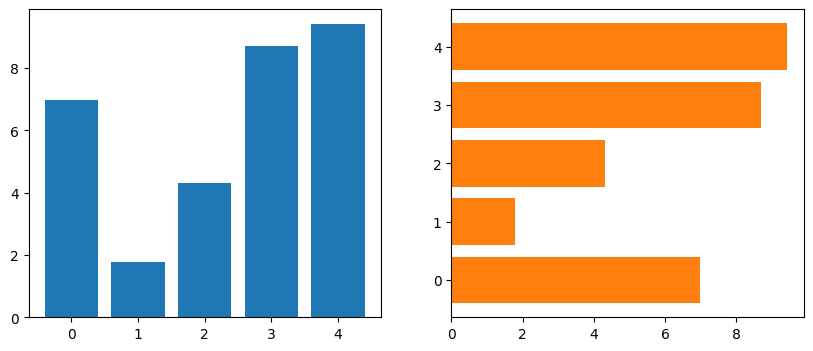

In [480]:
# bar / barh - vertical and horizontal bar charts
X = np.arange(5)
Y = np.random.uniform(1, 10, 5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(X, Y, color="C0")
ax2.barh(X, Y, color="C1")
plt.show()

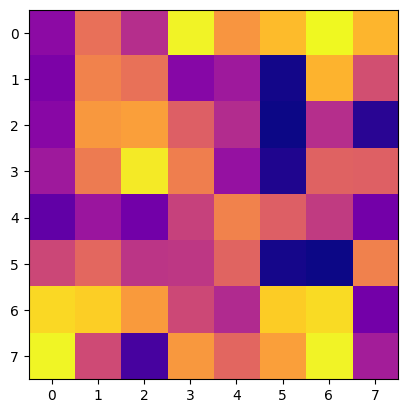

In [481]:
# imshow - 2D array as a colour image
Z = np.random.uniform(0, 1, (8, 8))

fig, ax = plt.subplots()
ax.imshow(Z, cmap="plasma", interpolation="nearest")
plt.show()

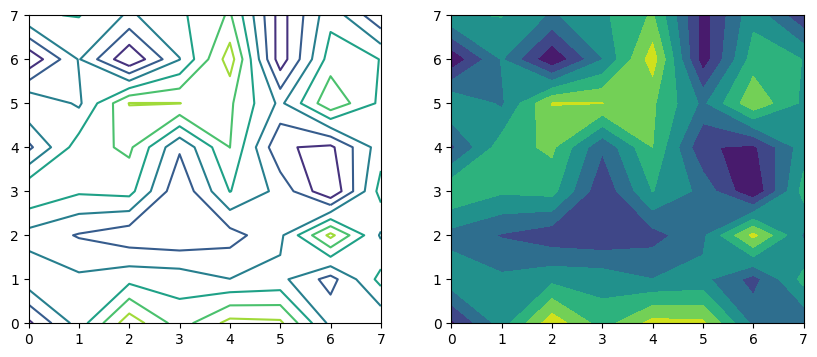

In [482]:
# contour / contourf - level curves and filled contours
Z = np.random.uniform(0, 1, (8, 8))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.contour(Z)
ax2.contourf(Z)
plt.show()

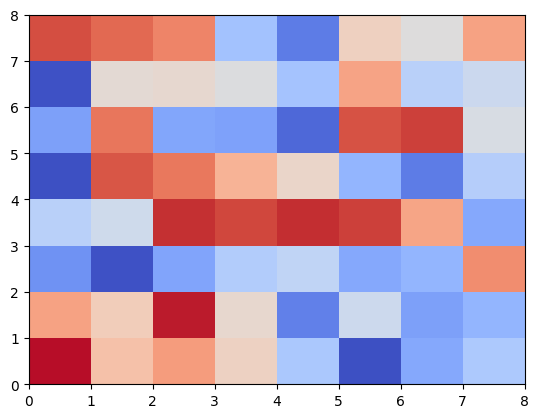

In [483]:
# pcolormesh - irregular or regular grid coloured by value; faster than imshow
# for non-uniform grids
Z = np.random.uniform(0, 1, (8, 8))

fig, ax = plt.subplots()
ax.pcolormesh(Z, vmin=0, vmax=1, cmap="coolwarm")
plt.show()

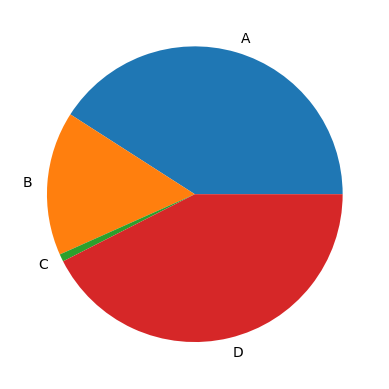

In [484]:
# pie chart
Z = np.random.uniform(0, 1, 4)

fig, ax = plt.subplots()
ax.pie(Z, labels=["A", "B", "C", "D"])
plt.show()

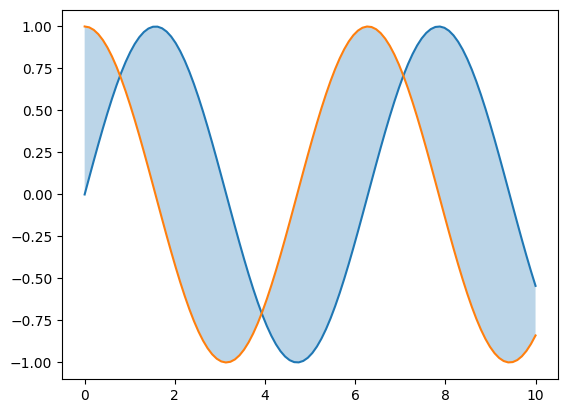

In [485]:
# fill_between - shade between two Y curves
X = np.linspace(0, 10, 100)
Y1 = np.sin(X)
Y2 = np.cos(X)

fig, ax = plt.subplots()
ax.plot(X, Y1, X, Y2)
ax.fill_between(X, Y1, Y2, alpha=0.3)
plt.show()

## Advanced Plots API

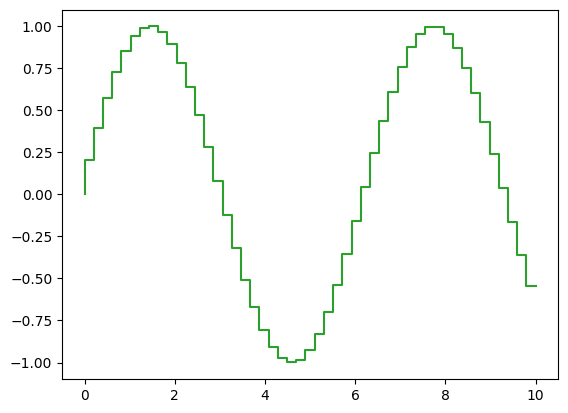

In [486]:
X = np.linspace(0, 10, 50)
Y = np.sin(X)

# step - staircase line; useful for discrete distributions and histograms
fig, ax = plt.subplots()
ax.step(X, Y, color="C2")
plt.show()

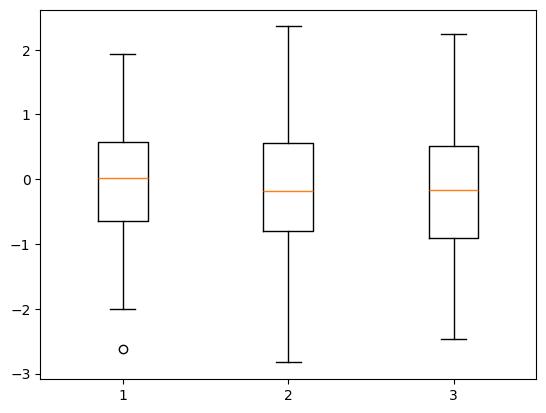

In [487]:
# boxplot - distribution summary with median, quartiles, and outliers
Z = np.random.normal(0, 1, (100, 3))

fig, ax = plt.subplots()
ax.boxplot(Z)
plt.show()

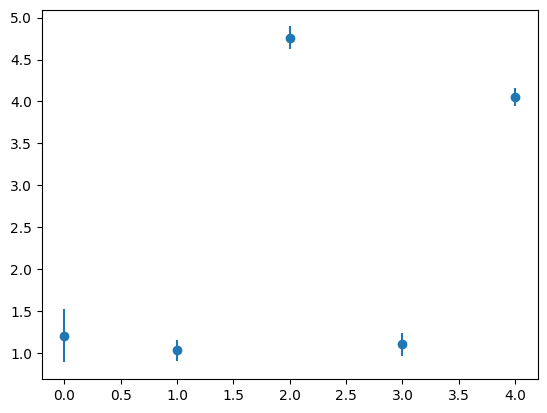

In [488]:
# errorbar - data points with symmetric or asymmetric error ranges
X = np.arange(5)
Y = np.random.uniform(1, 5, 5)
yerr = np.random.uniform(0.1, 0.5, 5)

fig, ax = plt.subplots()
ax.errorbar(X, Y, xerr=None, yerr=yerr, fmt="o")
plt.show()

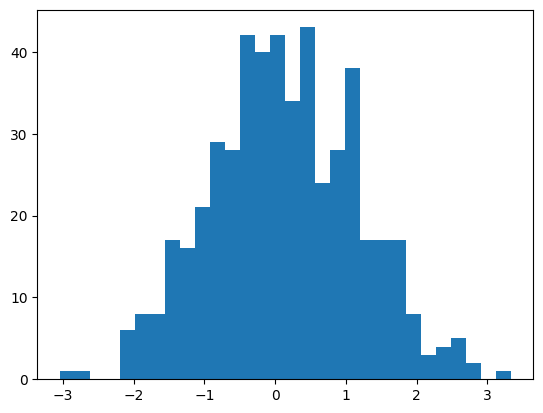

In [489]:
# hist - frequency distribution; bins= sets the number of bins
Z = np.random.normal(0, 1, 500)

fig, ax = plt.subplots()
ax.hist(Z, bins=30)
plt.show()

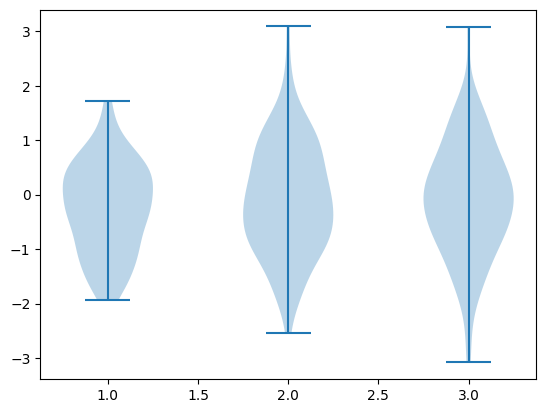

In [490]:
# violinplot - distribution shape via kernel density estimation
Z = np.random.normal(0, 1, (100, 3))

fig, ax = plt.subplots()
ax.violinplot(Z, positions=[1, 2, 3])
plt.show()

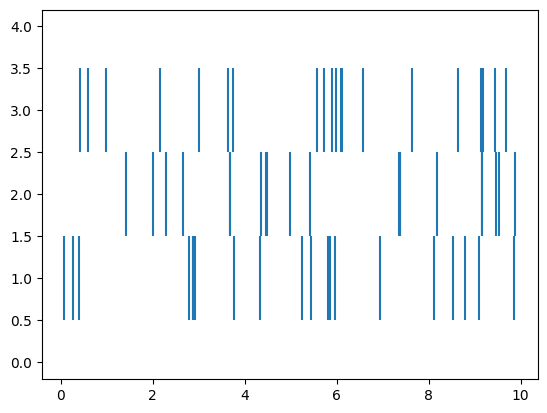

In [491]:
# eventplot - marks along an axis; common for spike trains in neuroscience
positions = [np.random.uniform(0, 10, 20) for _ in range(3)]

fig, ax = plt.subplots()
ax.eventplot(positions, orientation="horizontal", lineoffsets=[1, 2, 3])
plt.show()

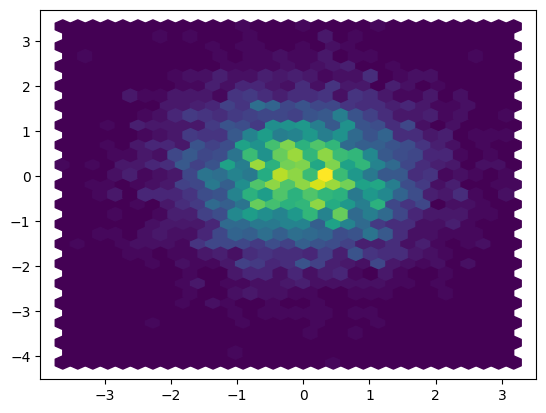

In [492]:
# hexbin - 2D histogram using hexagonal bins; better than scatter for dense data
X = np.random.normal(0, 1, 5000)
Y = np.random.normal(0, 1, 5000)

fig, ax = plt.subplots()
ax.hexbin(X, Y, C=None, gridsize=30)
plt.show()

## Scales and Projections

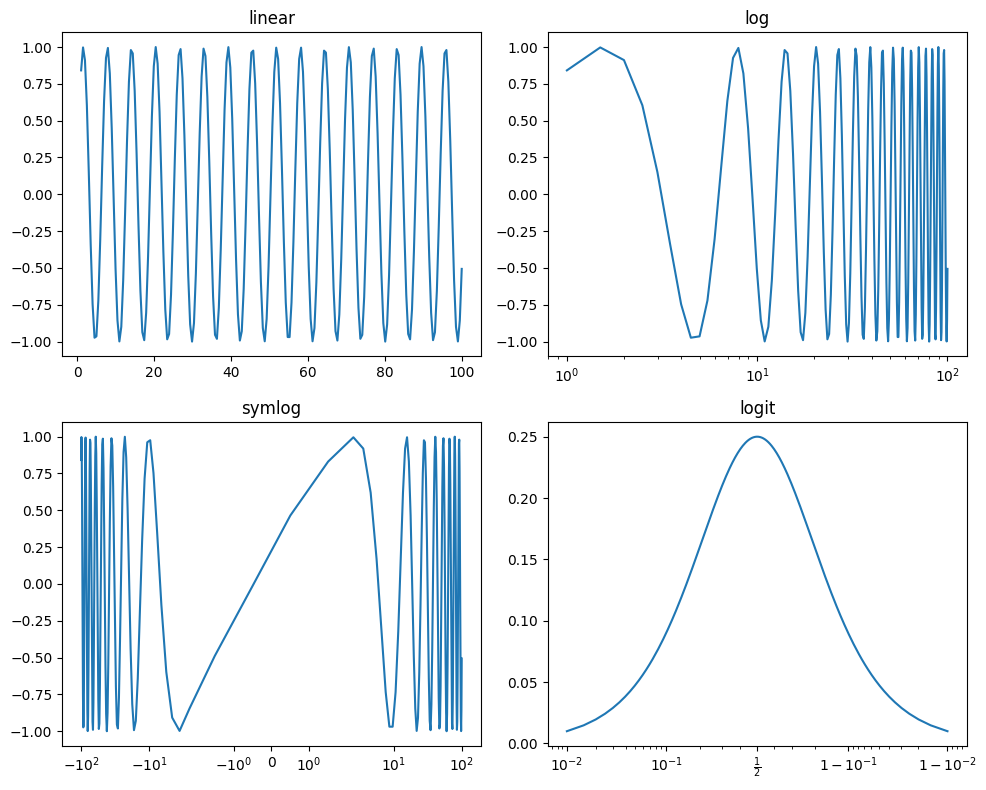

In [493]:
X = np.linspace(1, 100, 200)
Y = np.sin(X)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# linear - the default
axes[0, 0].plot(X, Y)
axes[0, 0].set_title("linear")

# log - compresses large ranges; values must be positive
axes[0, 1].set_xscale("log")
axes[0, 1].plot(X, Y)
axes[0, 1].set_title("log")

# symlog - log scale that handles negative values
axes[1, 0].set_xscale("symlog")
axes[1, 0].plot(np.linspace(-100, 100, 200), Y)
axes[1, 0].set_title("symlog")

# logit - for probabilities strictly between 0 and 1
p = np.linspace(0.01, 0.99, 200)
axes[1, 1].set_xscale("logit")
axes[1, 1].plot(p, p * (1 - p))
axes[1, 1].set_title("logit")

fig.tight_layout()
plt.show()

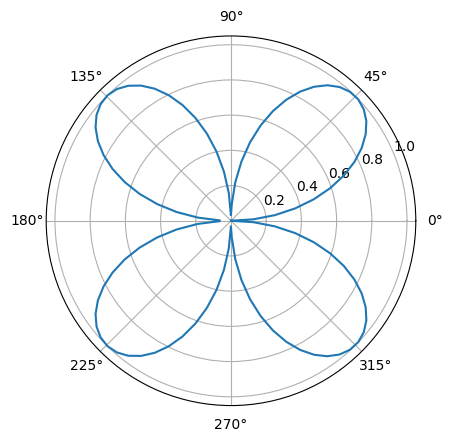

In [494]:
# Polar projection - specify via subplot keyword
fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(theta, np.abs(np.sin(2*theta)))
plt.show()

## Tick Locators

Locators decide where ticks appear on an axis. Import from
`matplotlib.ticker`.

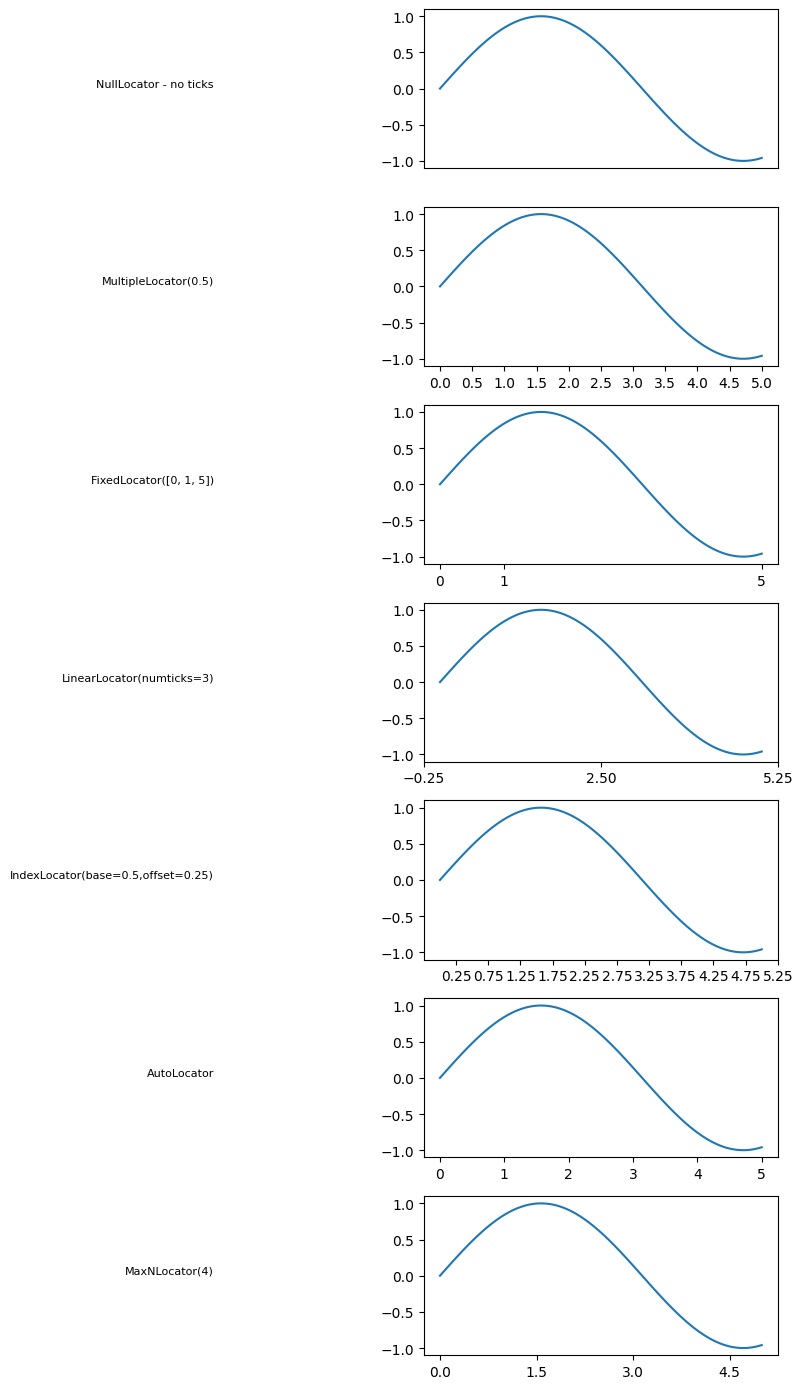

In [495]:
from matplotlib import ticker

fig, axes = plt.subplots(7, 1, figsize=(8, 14))
X = np.linspace(0, 5, 100)

locators = [
    ("NullLocator - no ticks",          ticker.NullLocator()),
    ("MultipleLocator(0.5)",            ticker.MultipleLocator(0.5)),
    ("FixedLocator([0, 1, 5])",         ticker.FixedLocator([0, 1, 5])),
    ("LinearLocator(numticks=3)",       ticker.LinearLocator(numticks=3)),
    ("IndexLocator(base=0.5,offset=0.25)", ticker.IndexLocator(base=0.5, offset=0.25)),
    ("AutoLocator",                     ticker.AutoLocator()),
    ("MaxNLocator(4)",                ticker.MaxNLocator(4)),
]

for ax, (label, locator) in zip(axes, locators):
    ax.plot(X, np.sin(X))
    ax.xaxis.set_major_locator(locator)
    ax.set_ylabel(label, fontsize=8, rotation=0, ha="right", labelpad=120)

fig.tight_layout()
plt.show()

## Tick Formatters

Formatters control how tick values are displayed as text.

/tmp/ipykernel_5523/2207768074.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.xaxis.set_major_formatter(formatter)


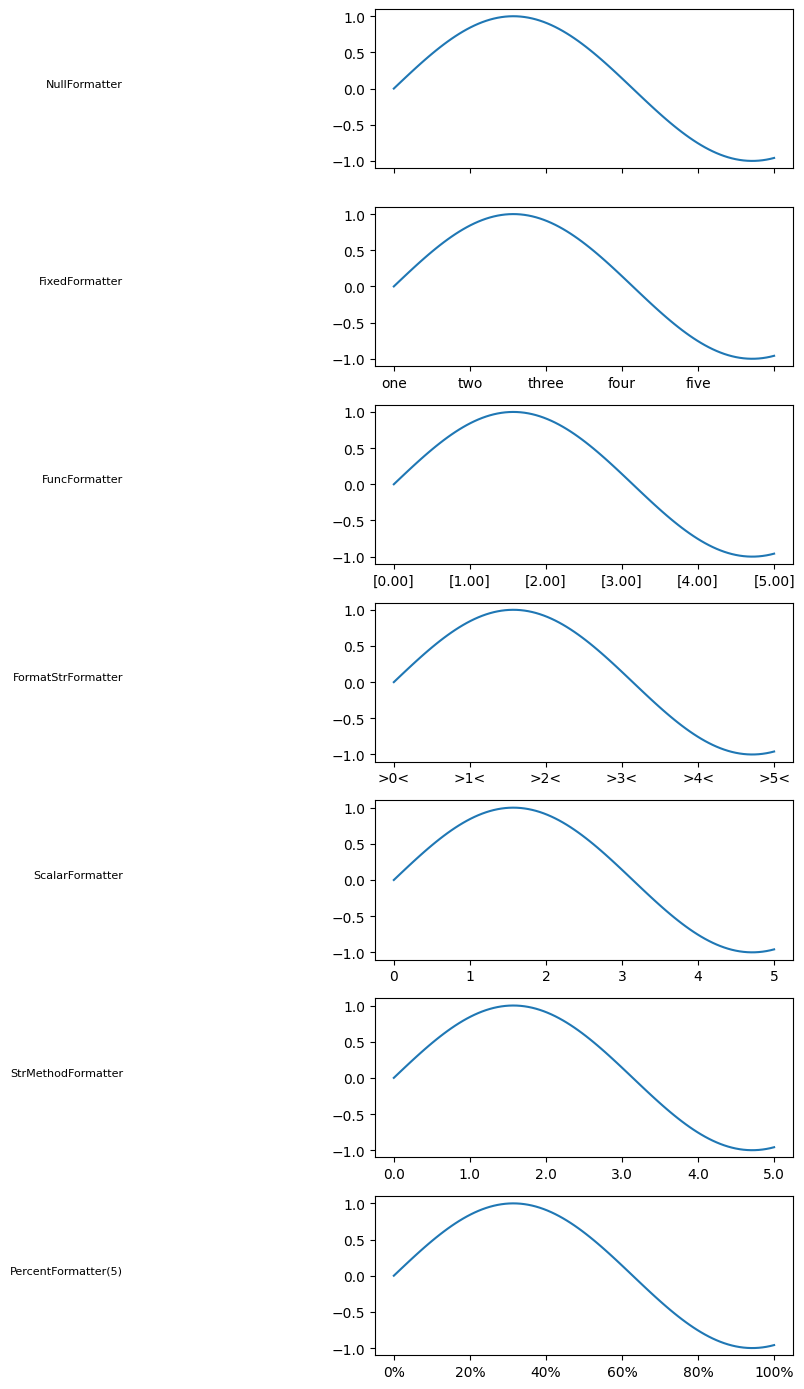

In [496]:
fig, axes = plt.subplots(7, 1, figsize=(8, 14))
X = np.linspace(0, 5, 100)

formatters = [
    ("NullFormatter",           ticker.NullFormatter()),
    ("FixedFormatter",          ticker.FixedFormatter(["zero", "one", "two", "three", "four", "five"])),
    ("FuncFormatter",           ticker.FuncFormatter(lambda x, pos: "[%.2f]" % x)),
    ("FormatStrFormatter",      ticker.FormatStrFormatter(">%d<")),
    ("ScalarFormatter",         ticker.ScalarFormatter()),
    ("StrMethodFormatter",      ticker.StrMethodFormatter("{x}")),
    ("PercentFormatter(5)",ticker.PercentFormatter(xmax=5)),
]

for ax, (label, formatter) in zip(axes, formatters):
    ax.plot(X, np.sin(X))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_major_formatter(formatter)
    ax.set_ylabel(label, fontsize=8, rotation=0, ha="right", labelpad=150)

fig.tight_layout()
plt.show()

## Ornaments: Legend, Colourbar, Annotate

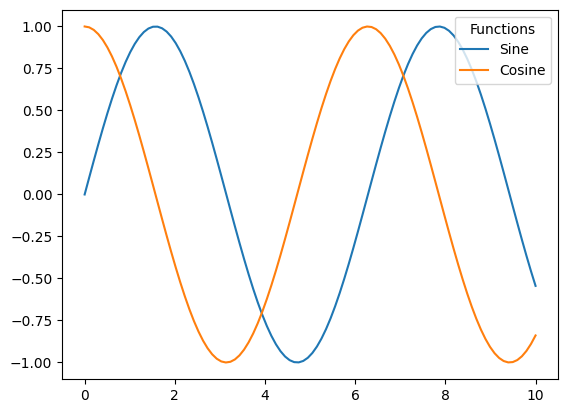

In [497]:
X = np.linspace(0, 10, 100)

# Legend - pass loc= string or numeric code, or use bbox_to_anchor for exact placement
fig, ax = plt.subplots()
ax.plot(X, np.sin(X), label="Sine")
ax.plot(X, np.cos(X), label="Cosine")
ax.legend(
    handles=None,       # None means auto-detect from labelled artists
    loc="upper right",  # string or numeric: 1=upper right, 2=upper left, etc.
    title="Functions",
    frameon=True,
)
plt.show()

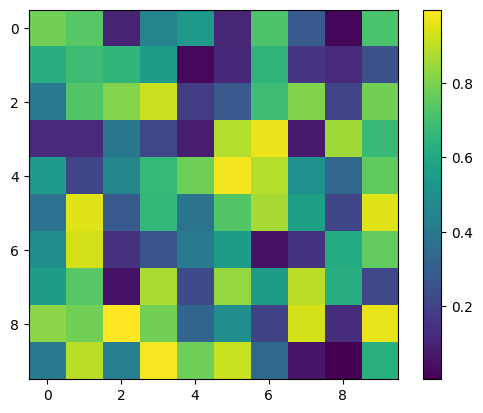

In [498]:
# Colourbar - attach to an image or any mappable artist
Z = np.random.uniform(0, 1, (10, 10))

fig, ax = plt.subplots()
im = ax.imshow(Z, cmap="viridis")
plt.colorbar(im, ax=ax, orientation="vertical")
plt.show()

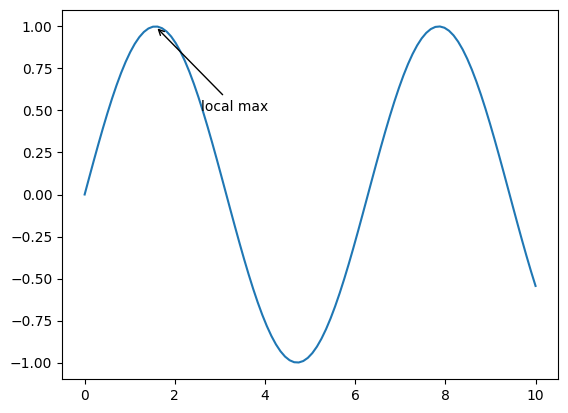

In [499]:
# Annotate - text with an arrow; xycoords and textcoords control the
# coordinate system for the point and the label respectively
fig, ax = plt.subplots()
ax.plot(X, np.sin(X))
ax.annotate(
    "local max",
    xy=(np.pi / 2, 1),          # the point being annotated
    xytext=(np.pi / 2 + 1, 0.5),# where the label appears
    arrowprops={"arrowstyle": "->"},
)
plt.show()

## Subplots Layout API

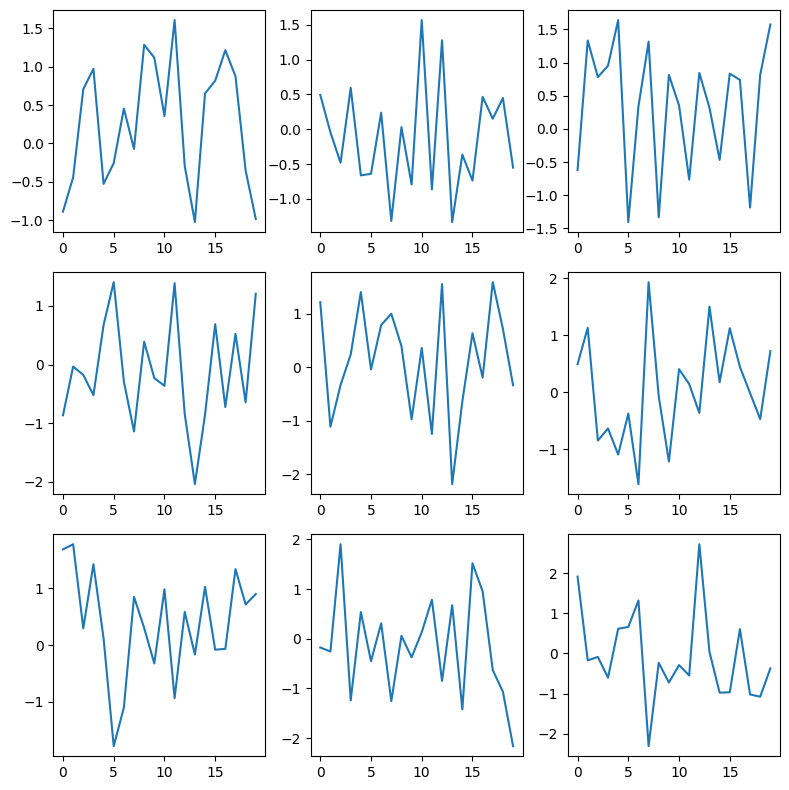

In [500]:
# plt.subplots(rows, cols) - uniform grid
fig, axs = plt.subplots(3, 3, figsize=(8, 8))
for ax in axs.flat:
    ax.plot(np.random.randn(20))
fig.tight_layout()
plt.show()

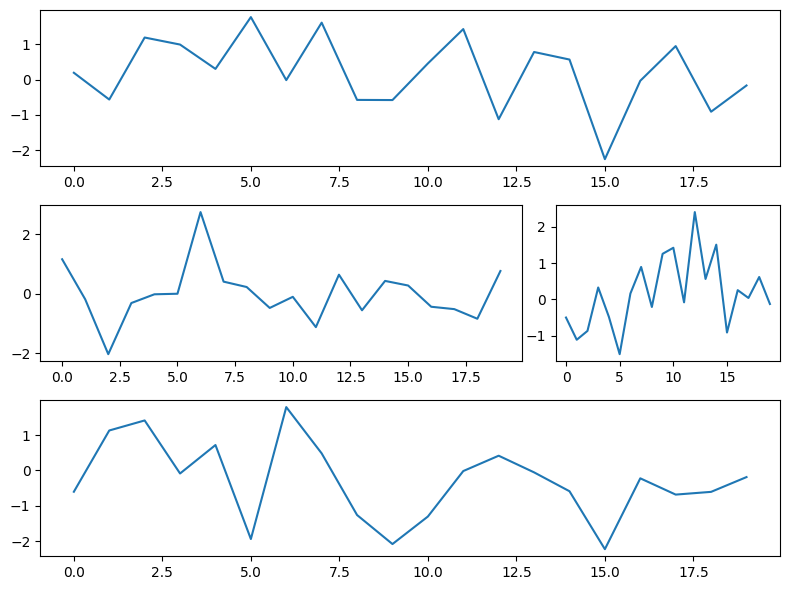

In [501]:
# GridSpec - variable-sized cells
fig = plt.figure(figsize=(8, 6))
G = mpl.gridspec.GridSpec(3, 3, figure=fig)
ax_top = fig.add_subplot(G[0, :])       # full top row
ax_mid_left = fig.add_subplot(G[1, :2]) # middle-left spanning 2 columns
ax_mid_right = fig.add_subplot(G[1, 2]) # middle-right single cell
ax_bot = fig.add_subplot(G[2, :])       # full bottom row

for ax in [ax_top, ax_mid_left, ax_mid_right, ax_bot]:
    ax.plot(np.random.randn(20))
fig.tight_layout()
plt.show()

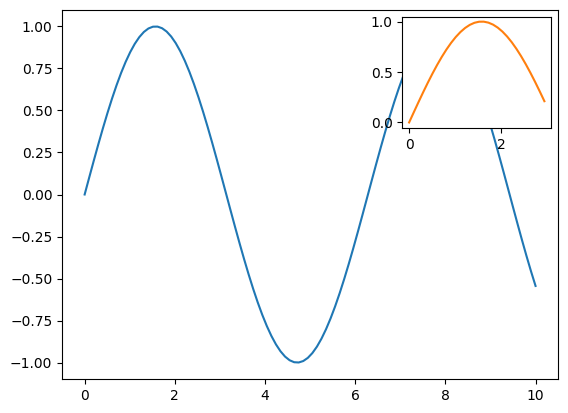

In [502]:
# inset_axes - a small axes embedded inside a larger one
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots()
ax.plot(X, np.sin(X))

# Place a small inset in the upper right
ax_inset = inset_axes(ax, width="30%", height="30%", loc="upper right")
ax_inset.plot(X[:30], np.sin(X[:30]), color="C1")
plt.show()

## Event Handling API

Matplotlib figures can respond to user input such as mouse clicks or key
presses using `fig.canvas.mpl_connect`. This is useful for interactive
exploratory tools.

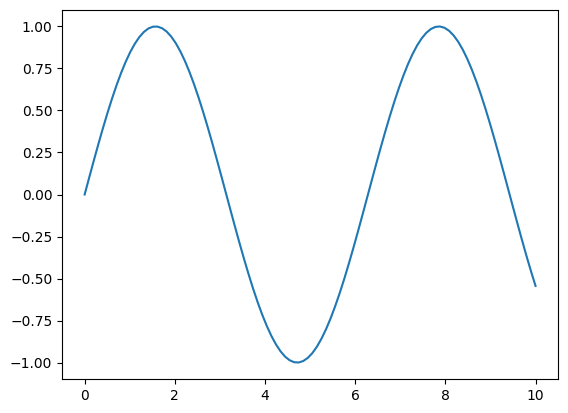

In [503]:
fig, ax = plt.subplots()
ax.plot(X, np.sin(X))

def on_click(event):
    print(f"Button {event.button} clicked at ({event.xdata:.2f}, {event.ydata:.2f})")

fig.canvas.mpl_connect("button_press_event", on_click)
plt.show()

## Animation API

`FuncAnimation` calls an `animate` function repeatedly, updating the plot
data each frame. `interval` is the delay between frames in milliseconds.

/tmp/ipykernel_5523/4215474430.py:12: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = mpla.FuncAnimation(plt.gcf(), animate, interval=5)


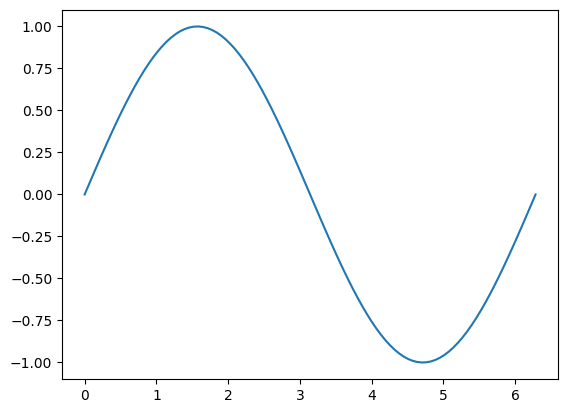

In [504]:
import matplotlib.animation as mpla

T = np.linspace(0, 2*np.pi, 100)
S = np.sin(T)

fig, ax = plt.subplots()
line, = ax.plot(T, S)

def animate(i):
    line.set_ydata(np.sin(T + i / 50))

anim = mpla.FuncAnimation(plt.gcf(), animate, interval=5)
plt.show()

## Styles API

`plt.style.use()` applies a complete visual theme. Set it once before any
plotting to change the look of all subsequent figures.

Available built-in styles include: `"default"`, `"classic"`, `"grayscale"`,
`"ggplot"`, `"seaborn-v0_8"`, `"fast"`, `"bmh"`, `"Solarize_Light2"`,
`"seaborn-v0_8-notebook"`.

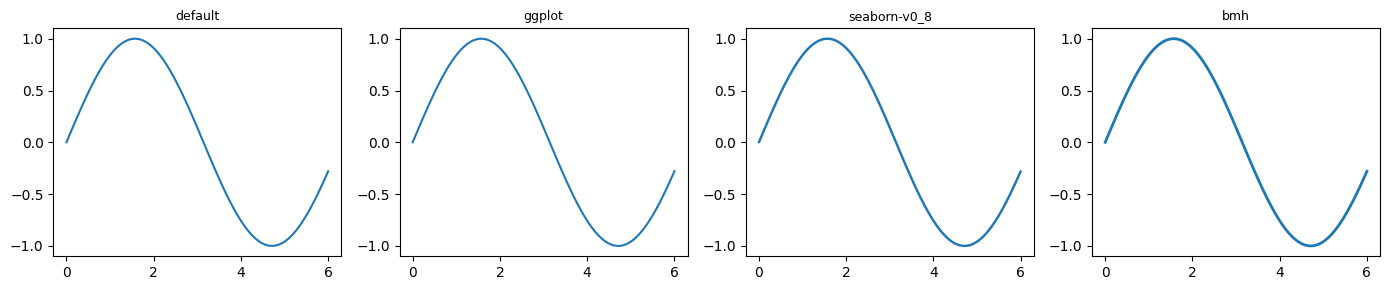

In [505]:
# Preview several styles side by side
styles = ["default", "ggplot", "seaborn-v0_8", "bmh"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

for ax, style in zip(axes, styles):
    with plt.style.context(style):
        ax.plot(np.linspace(0, 6, 100), np.sin(np.linspace(0, 6, 100)))
        ax.set_title(style, fontsize=9)

fig.tight_layout()
plt.show()

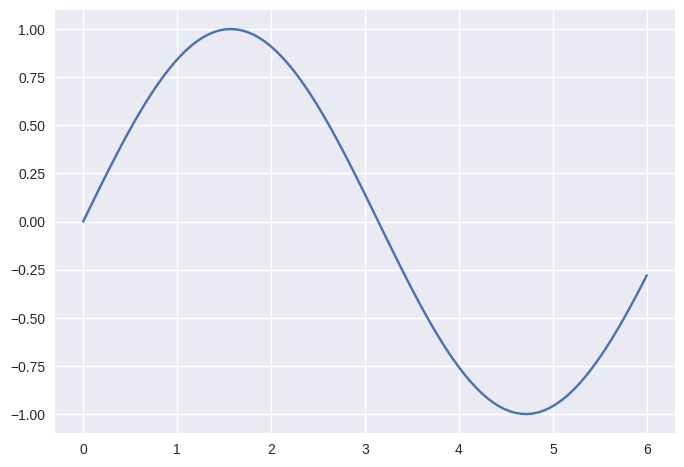

In [506]:
# Apply a style persistently for the rest of the session
plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots()
ax.plot(np.linspace(0, 6, 100), np.sin(np.linspace(0, 6, 100)))
plt.show()

# Reset to default
plt.style.use("default")

## Axes Adjustments

`plt.subplots_adjust()` controls the spacing between and around subplots.
All values are fractions of the figure width or height.

- `left`, `right`, `top`, `bottom` - outer margins
- `wspace` - horizontal space between columns
- `hspace` - vertical space between rows

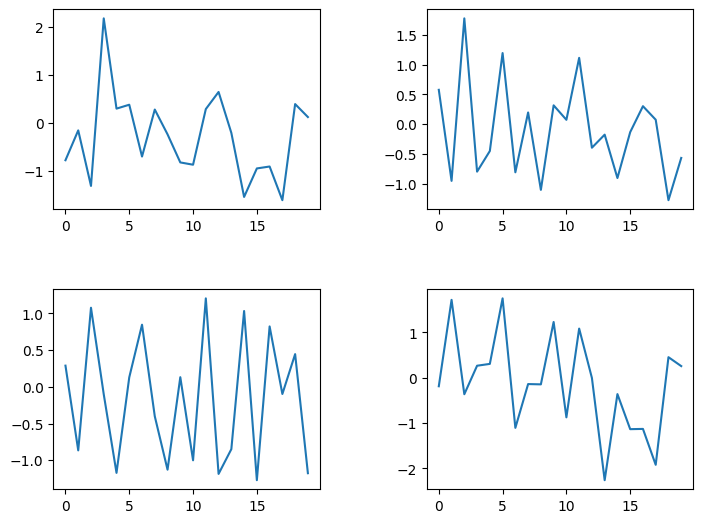

In [507]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
for ax in axs.flat:
    ax.plot(np.random.randn(20))

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1,
                    wspace=0.4, hspace=0.4)
plt.show()

## Text Alignment and Parameters

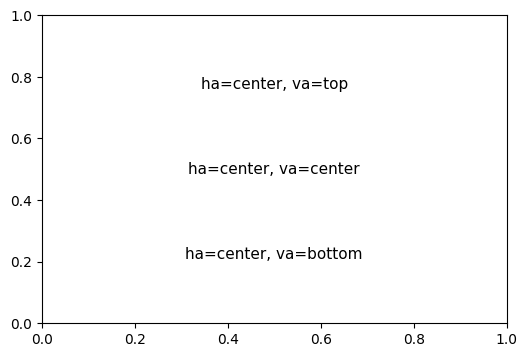

In [508]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# ha (horizontal alignment): "left", "center", "right"
# va (vertical alignment): "top", "center", "baseline", "bottom"
ax.text(0.5, 0.8, "ha=center, va=top",    ha="center", va="top",    fontsize=11)
ax.text(0.5, 0.5, "ha=center, va=center", ha="center", va="center", fontsize=11)
ax.text(0.5, 0.2, "ha=center, va=bottom", ha="center", va="bottom", fontsize=11)
plt.show()

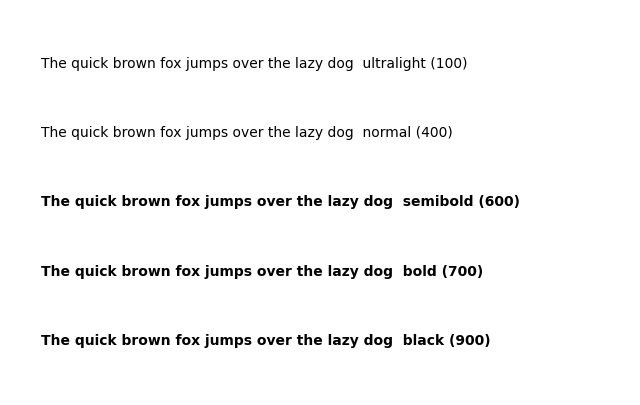

In [509]:
# Text weight and size
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

weights = [("ultralight", 100), ("normal", 400), ("semibold", 600),
           ("bold", 700), ("black", 900)]
for i, (name, weight) in enumerate(weights):
    ax.text(0.05, 0.85 - i * 0.18,
            f"The quick brown fox jumps over the lazy dog  {name} ({weight})",
            weight=name, fontsize=10)
plt.show()

## Quick Reminder Reference

These single-line calls are the most commonly needed `Axes` methods.
All can be chained or called individually after creating the plot.

```python
ax.grid()                        # toggle gridlines
ax.set_xlim(vmin, vmax)          # set X-axis limits
ax.set_ylim(vmin, vmax)          # set Y-axis limits
ax.set_xlabel("label")           # X-axis label
ax.set_ylabel("label")           # Y-axis label
ax.set_xticks(ticks, [labels])   # set tick positions and optional labels
ax.set_yticks(ticks, [labels])
ax.set_xticklabels(labels)       # override tick label text only
ax.set_title("title")            # subplot title
ax.tick_params(width=10)         # control tick appearance
ax.set_axis_on()                 # show axes
ax.set_axis_off()                # hide axes
fig.suptitle("title")            # figure-level title
fig.tight_layout()               # remove excess white space
plt.gcf()                        # get current Figure
plt.gca()                        # get current Axes
mpl.rc("axes", linewidth=1)      # set global defaults via rcParams
fig.patch.set_alpha(0)           # transparent figure background
ax.patch.set_alpha(0)            # transparent axes background
text = r'$\frac{-e^{i\pi}}{2^n}$'  # LaTeX maths in strings
```

## How Do I ...

Practical one-liner recipes from the official cheatsheet.

```python
# Resize a figure
fig.set_size_inches(w, h)

# Save a figure
fig.savefig("figure.pdf")

# Save a transparent figure
fig.savefig("figure.pdf", transparent=True)

# Clear a figure / an axes
fig.clear()
ax.clear()

# Close all figures
plt.close("all")

# Remove ticks
ax.set_xticks([])
ax.set_yticks([])

# Remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])

# Rotate tick labels
ax.tick_params(axis="x", rotation=90)

# Hide the top spine
ax.spines["top"].set_visible(False)

# Hide the legend border
ax.legend(frameon=False)

# Show error as a shaded region
ax.fill_between(X, Y + error, Y - error)

# Draw a rectangle
ax.add_patch(plt.Rectangle((0, 0), 1, 1))

# Draw a vertical line
ax.axvline(x=0.5)

# Draw outside the frame (clip off)
ax.plot(X, Y, clip_on=False)

# Use transparency
ax.plot(X, Y, alpha=0.25)

# Convert an RGB image to greyscale
gray = 0.2989 * R + 0.5870 * G + 0.1140 * B

# Set the figure background colour
fig.patch.set_facecolor("grey")

# Get a reversed colormap
plt.get_cmap("viridis_r")

# Get a discrete colormap (10 levels)
plt.get_cmap("viridis", 10)

# Show a figure for one second then close
import time
fig.show(block=False)
time.sleep(1)
```

## Performance Tips

From the cheatsheet - these substitutions can dramatically speed up rendering
for large datasets.

```python
# SLOW - scatter creates many individual Artist objects
ax.scatter(X, Y)

# FAST - a single Line2D with markers is much cheaper
ax.plot(X, Y, marker="o", ls="")

# SLOW - a separate plot call per point
for i in range(n):
    ax.plot(i, X[i], "o")

# FAST - one call for all points
ax.plot(X, marker="o", ls="")

# SLOW - clearing and redrawing the whole axes on every animation frame
ax.cla()
ax.imshow(new_data)
canvas.draw()

# FAST - update only the data array, leave everything else in place
im.set_data(new_data)
canvas.draw()
```

## Beyond Matplotlib

Matplotlib is the foundation, but several libraries extend it for specific
use cases:

- **Seaborn** - statistical data visualisation built on Matplotlib; higher-
  level API for heatmaps, regression plots, categorical distributions
- **Cartopy** - geospatial data processing and map projections
- **yt** - volumetric data visualisation for scientific simulations
- **mpld3** - converts Matplotlib figures to interactive D3.js charts for
  web browsers
- **Datashader** - renders very large datasets (millions of points) by
  aggregating before drawing
- **plotnine** - a grammar of graphics for Python, inspired by R's ggplot2

## Ten Simple Rules for Better Figures

From the official Matplotlib cheatsheet. These apply regardless of which
library you use.

1. Know your audience
2. Identify your message
3. Adapt the figure to the medium
4. Captions are not optional
5. Do not trust the defaults
6. Use colour effectively
7. Do not mislead the reader
8. Avoid chartjunk
9. Message trumps beauty
10. Get the right tool